1. Importar as bibliotecas

In [1]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Definir a variável "file" pelo nome da planilha.

In [2]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

3. Ler a planilha no Python.

In [3]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Origem_Residuo,Umidade_Residuo_pct,Poder_Calorifico_MJkg
0,Comercial,2.0,15.1
1,Comercial,2.0,17.9
2,Comercial,2.0,13.9
3,Comercial,2.0,18.8
4,Comercial,2.0,14.7
...,...,...,...
285,Residencial,77.0,6.5
286,Comercial,77.2,8.1
287,Residencial,77.6,3.6
288,Comercial,78.5,8.8


In [4]:
# Distribuicao de frequencia absoluta em classes de mesma amplitude
# (intervalos fechados a esquerda e abertos a direita: [a, b))
classes = range(0,125,25)
coluna = 'Umidade_Residuo_pct'
frequencia_pct_umidade = pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts().sort_index()
frequencia_pct_umidade

Umidade_Residuo_pct
[0, 25)      121
[25, 50)      50
[50, 75)     110
[75, 100)      9
Name: count, dtype: int64

In [5]:
# Frequencia relativa percentual de cada classe
frequencia_relativa_pct_umidade = round(pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts(normalize=True).sort_index() * 100, 2)
frequencia_relativa_pct_umidade

Umidade_Residuo_pct
[0, 25)      41.72
[25, 50)     17.24
[50, 75)     37.93
[75, 100)     3.10
Name: proportion, dtype: float64

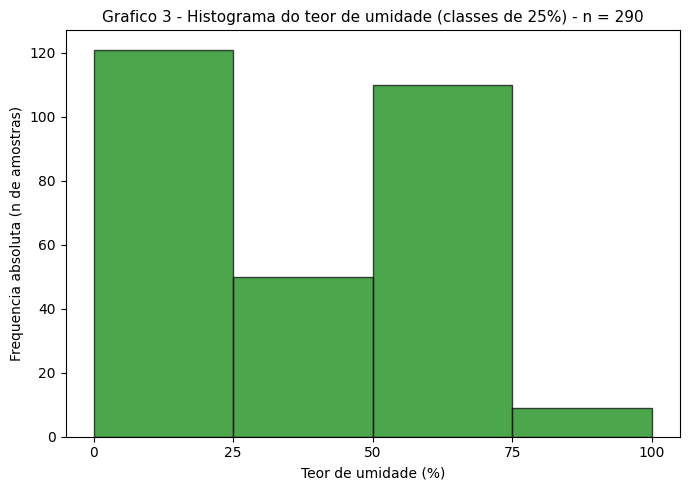

In [6]:
# Histograma 1: usa exatamente as classes da tabela de distribuicao de frequencias
classes = range(0,125,25)
plt.figure(figsize=(7, 5))
plt.hist(df.Umidade_Residuo_pct, bins=classes, rwidth=1, color='green', alpha=0.7, edgecolor='black')
plt.xticks(ticks=[0, 25, 50, 75, 100])
plt.xlabel("Teor de umidade (%)", size=10)
plt.ylabel("Frequencia absoluta (n de amostras)", size=10)
plt.title("Grafico 3 - Histograma do teor de umidade (classes de 25%) - n = 290", size=11)
plt.tight_layout()
plt.show()

**Histograma**

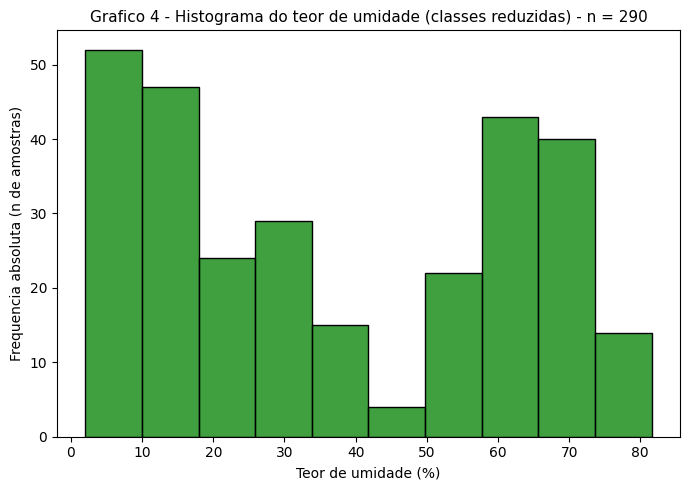

In [7]:
# Histograma 2: classes de menor amplitude, com finalidade exploratoria
# (intervalos mais estreitos revelam detalhes da forma da distribuicao)
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="Umidade_Residuo_pct", kde=False, color='green', edgecolor='black')
plt.xlabel("Teor de umidade (%)", size=10)
plt.ylabel("Frequencia absoluta (n de amostras)", size=10)
plt.title("Grafico 4 - Histograma do teor de umidade (classes reduzidas) - n = 290", size=11)
plt.tight_layout()
plt.show()

VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.

In [8]:
valormin=min(df.Umidade_Residuo_pct)
valormax=max(df.Umidade_Residuo_pct)
valormin,valormax

(2.0, 81.6)

**Medidas de Tendência Central**


*   Média, Moda e Mediana


In [9]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Umidade_Residuo_pct
df.Umidade_Residuo_pct.mean()

np.float64(37.009655172413794)

In [10]:
# com 2 casas decimais
df.Umidade_Residuo_pct.mean().round(2)

np.float64(37.01)

In [11]:
# cálculo da moda. Mesmas indicações
df.Umidade_Residuo_pct.mode()

0    2.0
Name: Umidade_Residuo_pct, dtype: float64

In [12]:
#cálculo da mediana.
df.Umidade_Residuo_pct.median()

np.float64(32.3)

In [13]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Umidade_Residuo_pct.describe().round(2)

count    290.00
mean      37.01
std       25.23
min        2.00
25%       13.92
50%       32.30
75%       62.12
max       81.60
Name: Umidade_Residuo_pct, dtype: float64

In [14]:
# Tabela final: frequencias absoluta, relativa, absoluta acumulada e relativa acumulada
tabela_umidade_residuos = pd.DataFrame({
    'Frequência absoluta': frequencia_pct_umidade,
    'Frequência relativa (%)': frequencia_relativa_pct_umidade
})
tabela_umidade_residuos['Frequência absoluta acumulada'] = tabela_umidade_residuos['Frequência absoluta'].cumsum()
tabela_umidade_residuos['Frequência relativa acumulada (%)'] = round(
    tabela_umidade_residuos['Frequência absoluta acumulada'] / tabela_umidade_residuos['Frequência absoluta'].sum() * 100, 2)

tabela_umidade_residuos = tabela_umidade_residuos.reset_index()
tabela_umidade_residuos = tabela_umidade_residuos.rename(columns={'Umidade_Residuo_pct': 'Intervalos', 'index': 'Intervalos'})

display(tabela_umidade_residuos)

,Intervalos,Frequência absoluta,Frequência relativa (%),Frequência absoluta acumulada,Frequência relativa acumulada (%)
0,"[0, 25)",121,41.72,121,41.72
1,"[25, 50)",50,17.24,171,58.97
2,"[50, 75)",110,37.93,281,96.90
3,"[75, 100)",9,3.10,290,100.00


In [15]:
tabela_umidade_residuos.to_excel("Tabela_Frequencia_Umidade.xlsx", sheet_name="Dados", index=False)

**Amplitude total do conjunto de dados**

In [16]:
# Amplitude total = maior valor observado - menor valor observado
amplitude = df.Umidade_Residuo_pct.max() - df.Umidade_Residuo_pct.min()
print("Valor minimo ...:", df.Umidade_Residuo_pct.min(), "%")
print("Valor maximo ...:", df.Umidade_Residuo_pct.max(), "%")
print("Amplitude total :", round(amplitude, 2), "%")

Valor minimo ...: 2.0 %
Valor maximo ...: 81.6 %
Amplitude total : 79.6 %
